In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.utilities import GoogleSerperAPIWrapper,WikipediaAPIWrapper
import logging
from langchain.agents.middleware import before_model, after_model
from langchain.agents.middleware import SummarizationMiddleware
#from langchain.middleware.summarization import SummarizationMiddleware
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
#from langchain_anthropic.middleware import anthropicPromptCachingMiddleware
from langchain.agents.middleware import TodoListMiddleware
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

# -----------------------------
# 1. Setup (same as your code)
# -----------------------------
path = "Understanding_Climate_Change.pdf"

docs = PyPDFLoader(path).load()

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)

retriever = vector_store.as_retriever(search_kwargs={"k": 5})


# -----------------------------
# 2. State Definition
# -----------------------------
class RAGState(TypedDict):
    query: str
    retrieved_docs: List[Document]
    reranked_docs: List[Document]


# -----------------------------
# 3. Reranker Schema
# -----------------------------
class RatingScore(BaseModel):
    relevance_score: float = Field(..., description="Relevance score (1-10)")


# -----------------------------
# 4. Nodes
# -----------------------------

# 🔹 Retrieve Node
def retrieve_node(state: RAGState):
    query = state["query"]
    docs = retriever.invoke(query)
    return {"retrieved_docs": docs}


# 🔹 Rerank Node
def rerank_node(state: RAGState):
    query = state["query"]
    docs = state["retrieved_docs"]

    prompt_template = PromptTemplate(
        input_variables=["query", "doc"],
        template="""On a scale of 1-10, rate the relevance of the following document to the query.
Consider intent, not just keyword overlap.

Query: {query}
Document: {doc}
Relevance Score:"""
    )

    llm = ChatOpenAI(
        temperature=0,
        model_name="gpt-4o",
        max_tokens=1000
    )

    chain = prompt_template | llm.with_structured_output(RatingScore)

    scored_docs = []
    for doc in docs:
        score = chain.invoke({
            "query": query,
            "doc": doc.page_content
        }).relevance_score

        try:
            score = float(score)
        except:
            score = 0

        scored_docs.append((doc, score))

    reranked = sorted(scored_docs, key=lambda x: x[1], reverse=True)

    return {"reranked_docs": [doc for doc, _ in reranked[:3]]}


# -----------------------------
# 5. Graph Definition
# -----------------------------
graph = StateGraph(RAGState)

graph.add_node("retrieve", retrieve_node)
graph.add_node("LLM_Based_Rerank", rerank_node)

graph.set_entry_point("retrieve")

graph.add_edge("retrieve", "LLM_Based_Rerank")
graph.add_edge("LLM_Based_Rerank", END)

app = graph.compile()


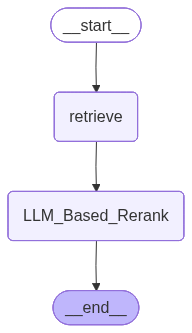

In [3]:
app

In [5]:

# -----------------------------
# 6. Run LLM based Reranking
# -----------------------------
query = "What are the causes of climate change?"

result = app.invoke({"query": query})

for i, doc in enumerate(result["reranked_docs"], 1):
    print(f"\n--- Top {i} ---")
    print(doc.page_content[:300])


--- Top 1 ---
Chapter 2: Causes of Climate Change 
Greenhouse Gases 
The primary cause of recent climate change is the increase in greenhouse gases in the 
atmosphere. Greenhouse gases, such as carbon dioxide (CO2), methane (CH4), and nitrous 
oxide (N2O), trap heat from the sun, creating a "greenhouse effect." T

--- Top 2 ---
Most of these climate changes are attributed to very small variations in Earth's orbit that 
change the amount of solar energy our planet receives. During the Holocene epoch, which 
began at the end of the last ice age, human societies flourished, but the industrial era has seen 
unprecedented chang

--- Top 3 ---
Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate. The term 
"global climate" encompasses the planet's overall weather patterns, including temperature, 
precipitation, and wind patterns, over an exte
